# IDC Pretrained ResNet18 Comparison

This notebook trains a stronger comparison model using ImageNet-pretrained `ResNet18`.

Workflow:
- mount Google Drive
- reuse the cached dataset zip from Drive
- extract the dataset into `/content`
- read the cleaned `train/val/test` split CSVs from `artifacts/`
- resize patches to `128x128` for transfer learning
- apply ImageNet normalization
- fine-tune a pretrained `ResNet18`
- save the best checkpoint, history, and metrics


In [1]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# Notebook 05 trains the pretrained comparison model.
PROJECT_ROOT = Path('/content/drive/MyDrive/Workshop UDL')
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_ARCHIVE_PATH = PROJECT_ROOT / 'datasets' / 'Breast Cancer Histopathology Dataset.zip'
TRAINING_RUNS_DIR = PROJECT_ROOT / 'training_runs'

RUNTIME_DIR = Path('/content/idc_runtime')
RUNTIME_EXTRACT_DIR = RUNTIME_DIR / 'dataset'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'Source directory not found: {SRC_DIR}. '
        'Put the project folder in Google Drive so Colab can import src/idc_pipeline.'
    )

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'Dataset archive cache: {DATASET_ARCHIVE_PATH}')
print(f'Training runs dir: {TRAINING_RUNS_DIR}')
print(f'Runtime extract dir: {RUNTIME_EXTRACT_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Workshop UDL
Artifacts dir: /content/drive/MyDrive/Workshop UDL/artifacts
Dataset archive cache: /content/drive/MyDrive/Workshop UDL/datasets/Breast Cancer Histopathology Dataset.zip
Training runs dir: /content/drive/MyDrive/Workshop UDL/training_runs
Runtime extract dir: /content/idc_runtime/dataset


In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from idc_pipeline.download import prepare_dataset_from_cached_zip
from idc_pipeline.model import IMAGENET_NORMALIZATION_MEAN, IMAGENET_NORMALIZATION_STD
from idc_pipeline.train import TrainingConfig, run_training_experiment

required_artifacts = [
    ARTIFACTS_DIR / 'cleaning_summary.json',
    ARTIFACTS_DIR / 'splits' / 'train.csv',
    ARTIFACTS_DIR / 'splits' / 'val.csv',
    ARTIFACTS_DIR / 'splits' / 'test.csv',
]
missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = '\n'.join(str(path) for path in missing_artifacts)
    raise FileNotFoundError(
        'Missing cleaned split artifacts. Run notebook 01 first.\n'
        f'Missing files:\n{missing_text}'
    )

dataset_dir = prepare_dataset_from_cached_zip(
    archive_path=DATASET_ARCHIVE_PATH,
    extract_dir=RUNTIME_EXTRACT_DIR,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dataset ready at: {dataset_dir}')
print(f'PyTorch device: {device}')
print('If this is the first pretrained run in this runtime, torchvision may download ResNet18 ImageNet weights.')


Using existing extracted dataset: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Resolved canonical dataset directory: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Dataset ready at: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
PyTorch device: cuda
If this is the first pretrained run in this runtime, torchvision may download ResNet18 ImageNet weights.


In [3]:
train_csv_path = ARTIFACTS_DIR / 'splits' / 'train.csv'
val_csv_path = ARTIFACTS_DIR / 'splits' / 'val.csv'
test_csv_path = ARTIFACTS_DIR / 'splits' / 'test.csv'

# ResNet18 uses larger resized inputs plus ImageNet normalization because it is a pretrained backbone.
run_name = 'resnet18_transfer_seed42'
output_dir = TRAINING_RUNS_DIR / run_name

training_config = TrainingConfig(
    batch_size=64,
    epochs=10,
    learning_rate=1e-4,
    weight_decay=1e-4,
    num_workers=2,
    seed=42,
    early_stopping_patience=3,
    threshold=0.5,
    dropout=0.20,
    architecture='resnet18',
    pretrained=True,
    image_size=(128, 128),
    normalization_mean=IMAGENET_NORMALIZATION_MEAN,
    normalization_std=IMAGENET_NORMALIZATION_STD,
    selection_metric='roc_auc',
)

result = run_training_experiment(
    dataset_dir=dataset_dir,
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    output_dir=output_dir,
    config=training_config,
)

result


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 358MB/s]

Starting training on cuda | architecture=resnet18 | normalization=train_stats | color_jitter=0.00 | scheduler=none | train=193,281, val=40,963, test=40,978 | pos_weight=2.4828


Epoch 01/10 | 42.6s | lr=0.000100 | train_loss=0.4157 | val_loss=0.4605 | val_acc=0.8473 | val_f1=0.7660 | val_auc=0.9357 | best=yes
Epoch 02/10 | 42.5s | lr=0.000100 | train_loss=0.3627 | val_loss=0.4368 | val_acc=0.8618 | val_f1=0.7846 | val_auc=0.9444 | best=yes
Epoch 03/10 | 41.6s | lr=0.000100 | train_loss=0.3435 | val_loss=0.4747 | val_acc=0.8620 | val_f1=0.7793 | val_auc=0.9383 | best=no
Epoch 04/10 | 42.6s | lr=0.000100 | train_loss=0.3286 | val_loss=0.4672 | val_acc=0.8470 | val_f1=0.7707 | val_auc=0.9433 | best=no
Epoch 05/10 | 42.4s | lr=0.000100 | train_loss=0.3168 | val_loss=0.4631 | val_acc=0.8654 | val_f1=0.7823 | val_auc=0.9400 | best=no
Early stopping triggered after epoch 5. Best roc_auc was 0.9444 at epoch 2.
Training complete. Best epoch=2, best_roc_auc=0.9444, test_f1=0.8050, test_auc=0.9418
Saved checkpoint: /content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/best_model.pt


TrainingRunResult(output_dir=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42'), checkpoint_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/best_model.pt'), history_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/history.csv'), metrics_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/metrics.json'), config_path=PosixPath('/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/config.json'), best_epoch=2, best_metric_name='roc_auc', best_metric_value=0.9443528939286151, train_summary={'total': 193281, 'positive': 55496, 'negative': 137785}, val_summary={'total': 40963, 'positive': 11523, 'negative': 29440}, test_summary={'total': 40978, 'positive': 11749, 'negative': 29229}, pos_weight=2.4827915525443274, test_metrics={'loss': 0.4568070956801791, 'accuracy': 0.8828151691151349, 'precision': 0.769870250951

In [4]:
# The saved files have the same structure as the baseline runs, which keeps evaluation reusable.
print(json.dumps(result.to_dict(), indent=2))

with result.metrics_path.open() as handle:
    metrics_payload = json.load(handle)

history_df = pd.read_csv(result.history_path)
display(history_df)


{
  "output_dir": "/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42",
  "checkpoint_path": "/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/best_model.pt",
  "history_path": "/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/history.csv",
  "metrics_path": "/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/metrics.json",
  "config_path": "/content/drive/MyDrive/Workshop UDL/training_runs/resnet18_transfer_seed42/config.json",
  "best_epoch": 2,
  "best_metric_name": "roc_auc",
  "best_metric_value": 0.9443528939286151,
  "train_summary": {
    "total": 193281,
    "positive": 55496,
    "negative": 137785
  },
  "val_summary": {
    "total": 40963,
    "positive": 11523,
    "negative": 29440
  },
  "test_summary": {
    "total": 40978,
    "positive": 11749,
    "negative": 29229
  },
  "pos_weight": 2.4827915525443274,
  "best_val_metrics": {
    "loss": 0.43676975405030255,
    "ac

,epoch,learning_rate,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.0001,0.415675,0.876977,0.737766,0.886713,0.805411,0.948090,0.460471,0.847252,0.673064,0.888657,0.765980,0.935737
1,2,0.0001,0.362697,0.893751,0.766504,0.905921,0.830402,0.960313,0.436770,0.861802,0.698523,0.894993,0.784646,0.944353
2,3,0.0001,0.343496,0.899043,0.776993,0.909399,0.837998,0.964375,0.474675,0.862046,0.708523,0.865747,0.779284,0.938341
3,4,0.0001,0.328557,0.903017,0.784270,0.913507,0.843970,0.967398,0.467157,0.847033,0.666329,0.913825,0.770695,0.943266
4,5,0.0001,0.316830,0.907115,0.791623,0.918192,0.850223,0.969685,0.463103,0.865366,0.717555,0.859846,0.782283,0.939970


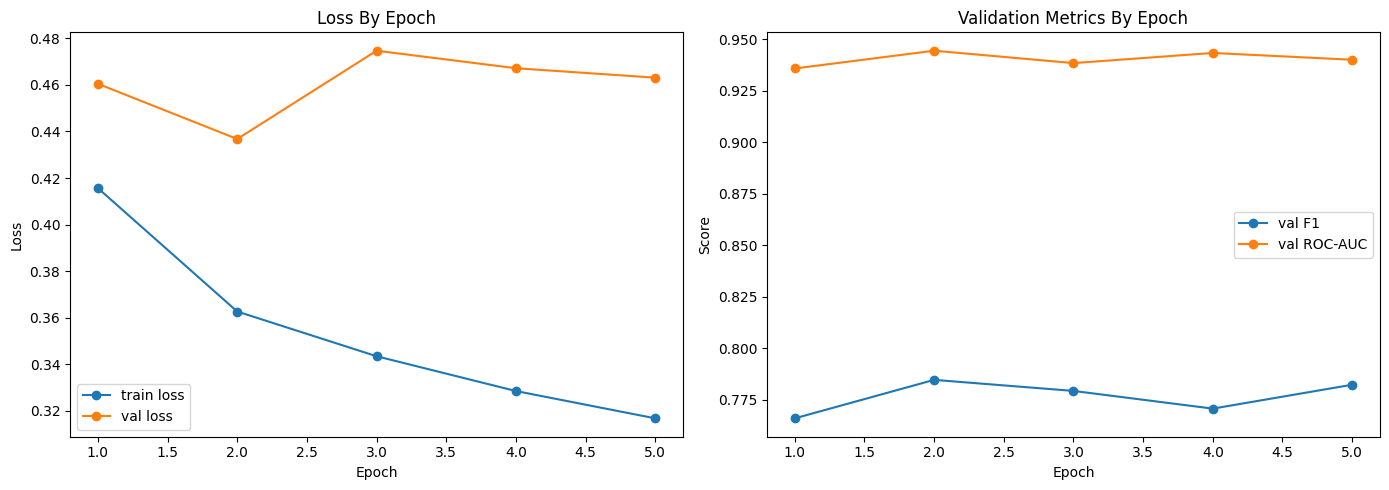

Best validation metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.43677,0.861802,0.698523,0.894993,0.784646,0.944353,10313,24989,4451,1210


Test metrics:


,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,0.456807,0.882815,0.76987,0.843391,0.804955,0.941809,9909,26267,2962,1840


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val loss')
axes[0].set_title('Loss By Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_f1'], marker='o', label='val F1')
axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
axes[1].set_title('Validation Metrics By Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Best validation metrics:')
display(pd.DataFrame([metrics_payload['best_val_metrics']]))

print('Test metrics:')
display(pd.DataFrame([metrics_payload['test_metrics']]))


## Outputs

Saved under `PROJECT_ROOT / 'training_runs' / run_name`:

- `best_model.pt`
- `history.csv`
- `metrics.json`
- `config.json`

This notebook uses the cleaned split CSVs from `artifacts/` and does not create new splits.
